In [28]:
DATOS_DIR = 'C:/Users/Peter/Desktop/all/Facu/Mineria De Datos Usando Sistemas Inteligentes/Datos/'          # carpeta donde se encuentran los datasets

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv(DATOS_DIR + 'Mental_Health_Lifestyle_Dataset.csv')
df

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Japan,57,Female,Moderate,Balanced,7.0,High,Depression,29,4.4,9.7,5.9
2996,Australia,27,Male,Low,Junk Food,7.1,Low,NaN,47,7.4,6.3,9.9
2997,Australia,42,Male,Moderate,Balanced,6.0,High,Depression,23,3.9,5.2,4.1
2998,Australia,25,Male,High,Keto,5.7,Low,Anxiety,51,4.3,5.9,4.1


In [31]:
df["Stress Level"].unique()

array(['Low', 'High', 'Moderate'], dtype=object)

In [32]:
# Verificar valores faltantes en el dataframe
df.isna().sum()

Country                          0
Age                              0
Gender                           0
Exercise Level                   0
Diet Type                        0
Sleep Hours                      0
Stress Level                     0
Mental Health Condition        595
Work Hours per Week              0
Screen Time per Day (Hours)      0
Social Interaction Score         0
Happiness Score                  0
dtype: int64

In [33]:
# Normalizar los atributos numéricos del dataframe
# Primero identificamos las columnas numéricas
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

# Creamos una copia del dataframe para no modificar el original
df_normalizado = df.copy()

# Aplicamos la normalización Min-Max a cada columna numérica
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Normalizamos solo las columnas numéricas
df_normalizado[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

# Mostramos las primeras filas del dataframe normalizado
print("Dataframe con atributos numéricos normalizados:")
df_normalizado.head()


Dataframe con atributos numéricos normalizados:


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,0.504264,Male,Low,Vegetarian,-0.117319,Low,NaN,-1.612844,-0.623853,0.908976,0.432091
1,Australia,-0.761919,Male,Moderate,Vegan,-1.050891,Low,PTSD,0.745328,0.063063,1.065037,0.549408
2,Japan,-0.315031,Female,Low,Vegetarian,0.482835,High,NaN,0.308629,-0.223152,1.611249,1.683473
3,Brazil,-0.463994,Male,Low,Vegan,0.482835,Low,Depression,0.308629,-1.654226,1.065037,0.471197
4,Germany,0.355301,Male,Low,Balanced,0.549519,Low,Anxiety,-0.390088,-0.852824,-0.300495,-0.389127


In [34]:
def matriz_correlacion(df):
    plt.figure(figsize=(10, 8))
    corr = df.select_dtypes(include=['int64', 'float64']).corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
    plt.title("Matriz de Correlación de Variables Numéricas", fontsize=16)
    plt.tight_layout()
    plt.show()

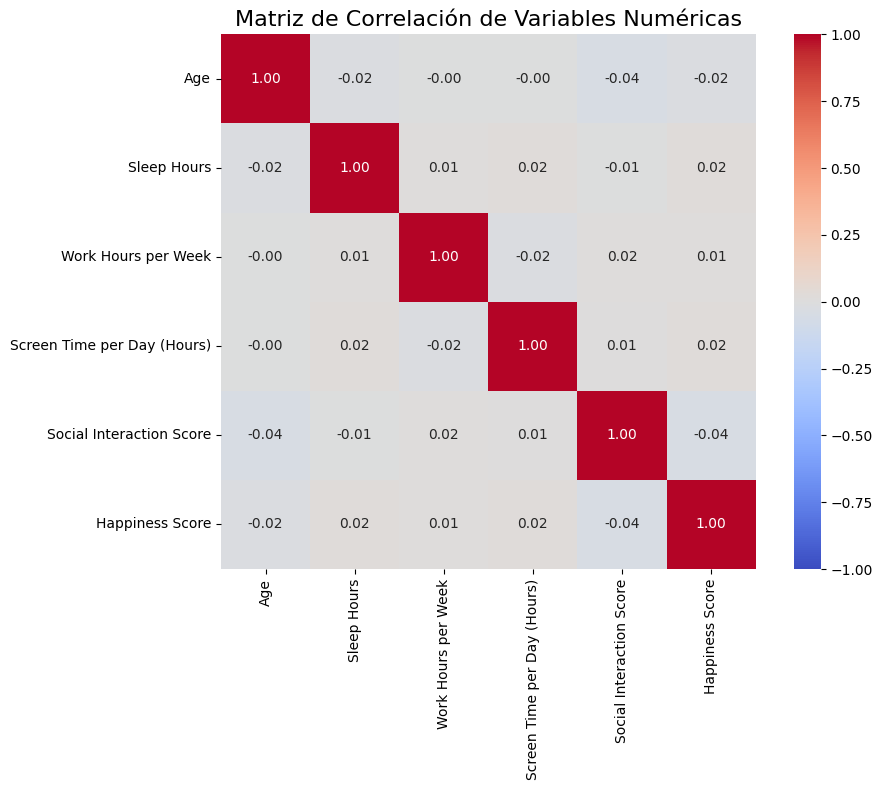

In [35]:
matriz_correlacion(df_normalizado)

Correlación entre nivel de estrés y nivel de actividad física: 0.0348


<Figure size 1000x600 with 0 Axes>

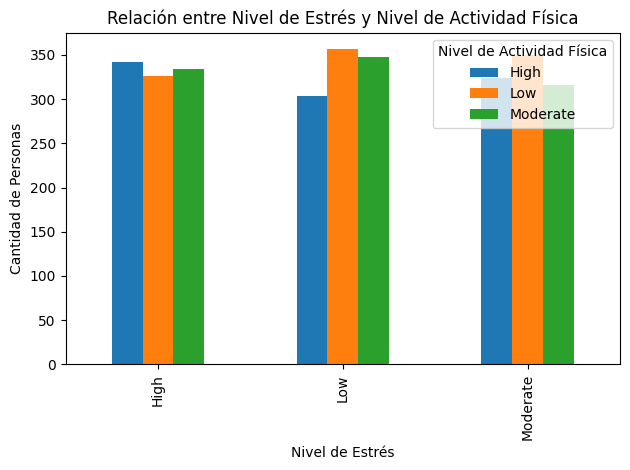

In [19]:
# Análisis de correlación entre nivel de estrés y nivel de actividad física

# Creamos un nuevo dataframe para no modificar el original
df_corr = df.copy()

# Asignamos valores específicos a las categorías de Stress Level y Exercise Level
# Stress Level: Low = 0, Moderate = 0.5, High = 1
# Exercise Level: Low = 0, Moderate = 0.5, High = 1
stress_mapping = {'Low': 0, 'Moderate': 0.5, 'High': 1}
exercise_mapping = {'Low': 0, 'Moderate': 0.5, 'High': 1}

# Aplicamos los mapeos
df_corr['Stress Level Encoded'] = df_corr['Stress Level'].map(stress_mapping)
df_corr['Exercise Level Encoded'] = df_corr['Exercise Level'].map(exercise_mapping)

# Calculamos la correlación entre las variables codificadas
corr_stress_exercise = df_corr['Stress Level Encoded'].corr(df_corr['Exercise Level Encoded'])

print(f"Correlación entre nivel de estrés y nivel de actividad física: {corr_stress_exercise:.4f}")

# Visualizamos la relación con un gráfico de barras
plt.figure(figsize=(10, 6))
stress_exercise_counts = df.groupby(['Stress Level', 'Exercise Level']).size().unstack()
stress_exercise_counts.plot(kind='bar', stacked=False)
plt.title('Relación entre Nivel de Estrés y Nivel de Actividad Física')
plt.xlabel('Nivel de Estrés')
plt.ylabel('Cantidad de Personas')
plt.legend(title='Nivel de Actividad Física')
plt.tight_layout()
plt.show()


In [23]:
df["Stress Level"] = df["Stress Level"].map(stress_mapping)
df["Exercise Level"] = df["Exercise Level"].map(exercise_mapping)

In [24]:
df

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,0.0,Vegetarian,6.3,0.0,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,0.5,Vegan,4.9,0.0,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,0.0,Vegetarian,7.2,1.0,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,0.0,Vegan,7.2,0.0,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,0.0,Balanced,7.3,0.0,Anxiety,35,3.6,4.7,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Japan,57,Female,0.5,Balanced,7.0,1.0,Depression,29,4.4,9.7,5.9
2996,Australia,27,Male,0.0,Junk Food,7.1,0.0,NaN,47,7.4,6.3,9.9
2997,Australia,42,Male,0.5,Balanced,6.0,1.0,Depression,23,3.9,5.2,4.1
2998,Australia,25,Male,1.0,Keto,5.7,0.0,Anxiety,51,4.3,5.9,4.1


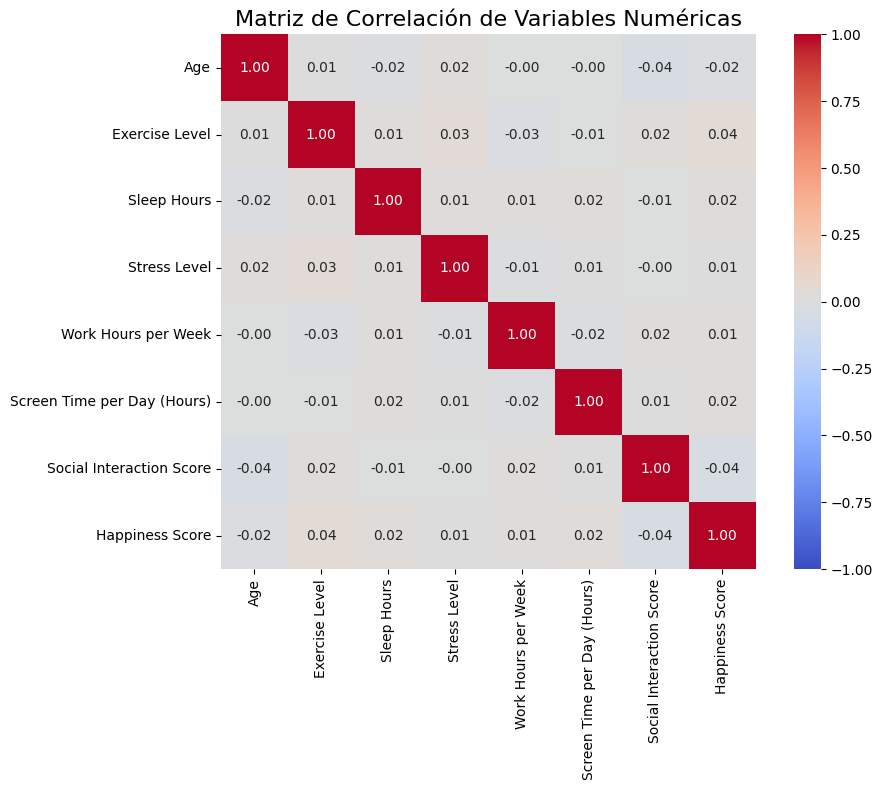

In [25]:
matriz_correlacion(df)

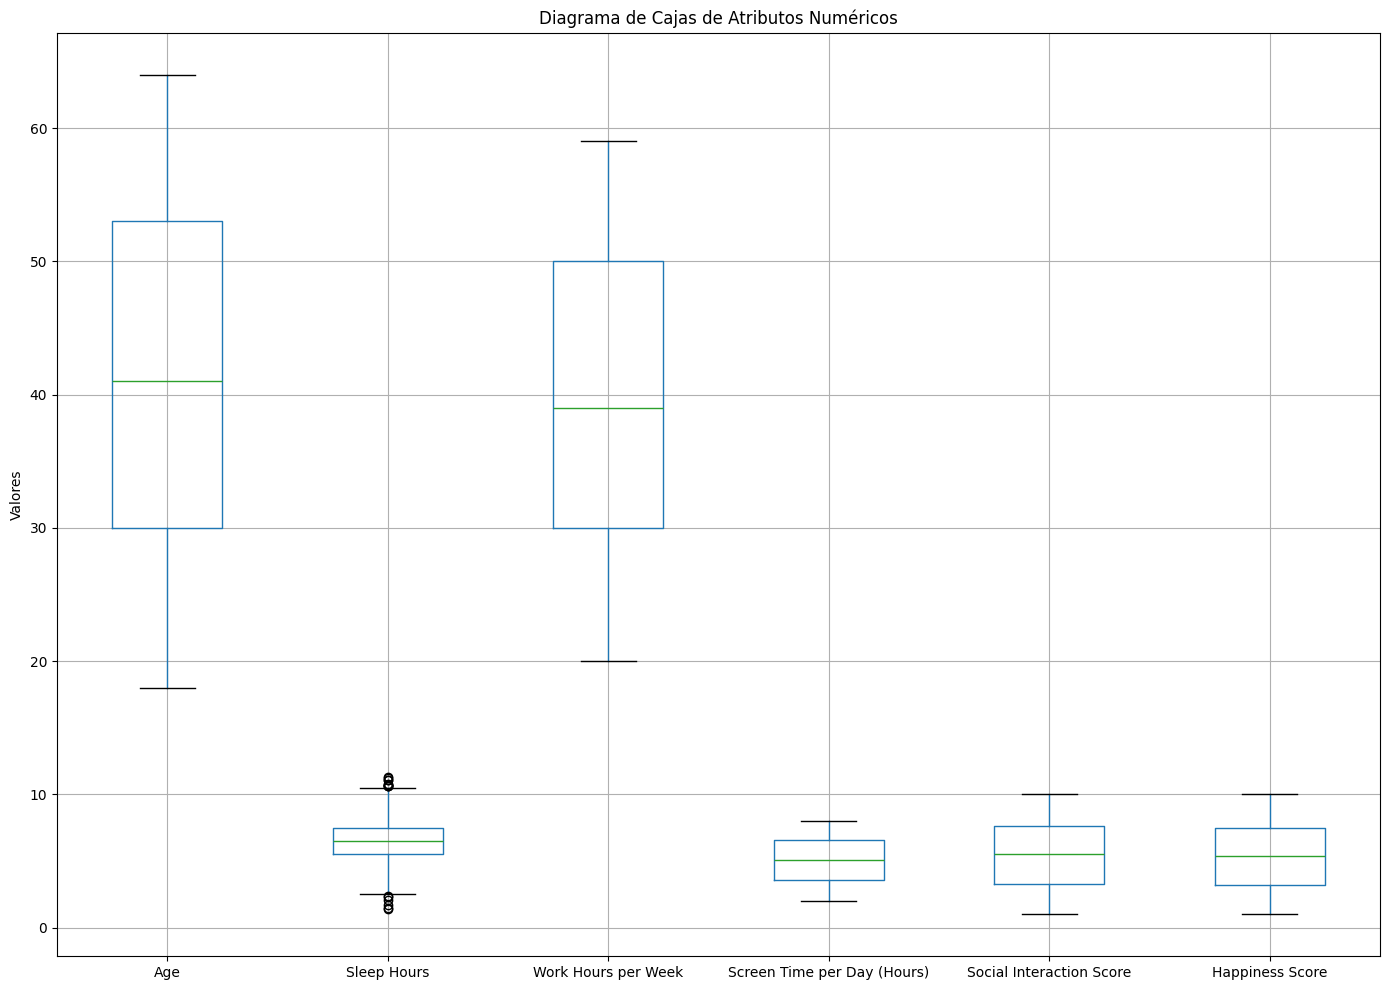

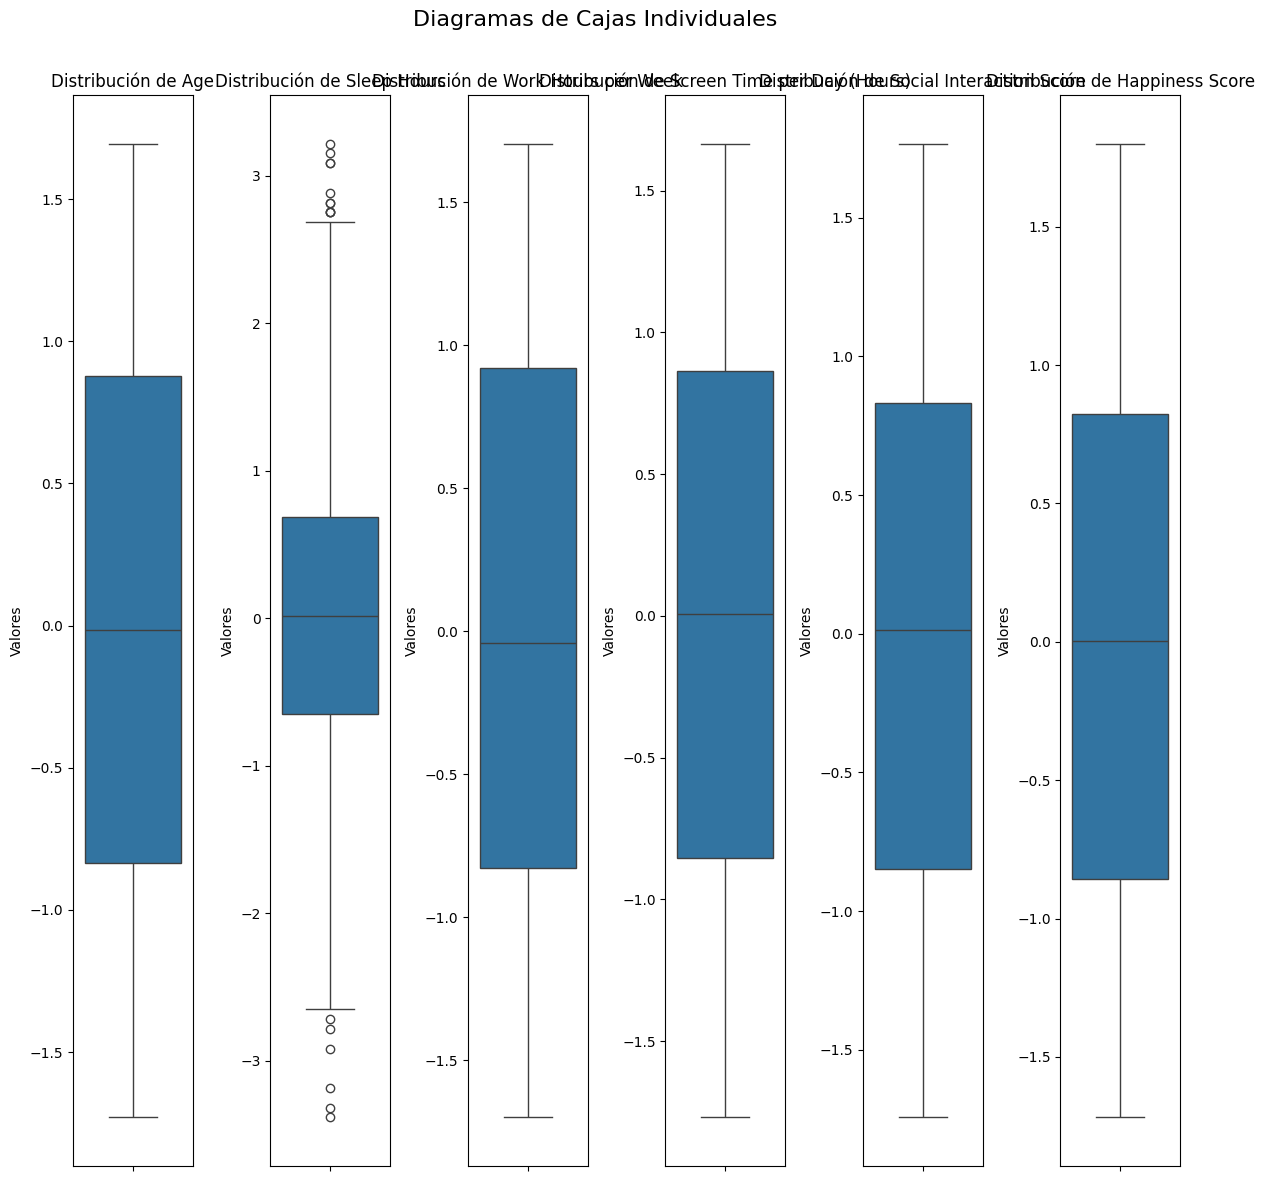

In [39]:
# Creamos un diagrama de cajas para los atributos numéricos
plt.figure(figsize=(14, 10))

# Seleccionamos solo las columnas numéricas
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

# Creamos el diagrama de cajas vertical
df[columnas_numericas].boxplot(vert=True, figsize=(14, 10))
plt.title('Diagrama de Cajas de Atributos Numéricos')
plt.ylabel('Valores')
plt.tight_layout()
plt.show()

# También podemos crear diagramas de cajas individuales para una mejor visualización
fig, axes = plt.subplots(1, len(columnas_numericas), figsize=(len(columnas_numericas)*2, 12), sharey=False)
fig.suptitle('Diagramas de Cajas Individuales', fontsize=16)

for i, columna in enumerate(columnas_numericas):
    sns.boxplot(y=df_normalizado[columna], ax=axes[i])
    axes[i].set_title(f'Distribución de {columna}')
    axes[i].set_ylabel('Valores')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


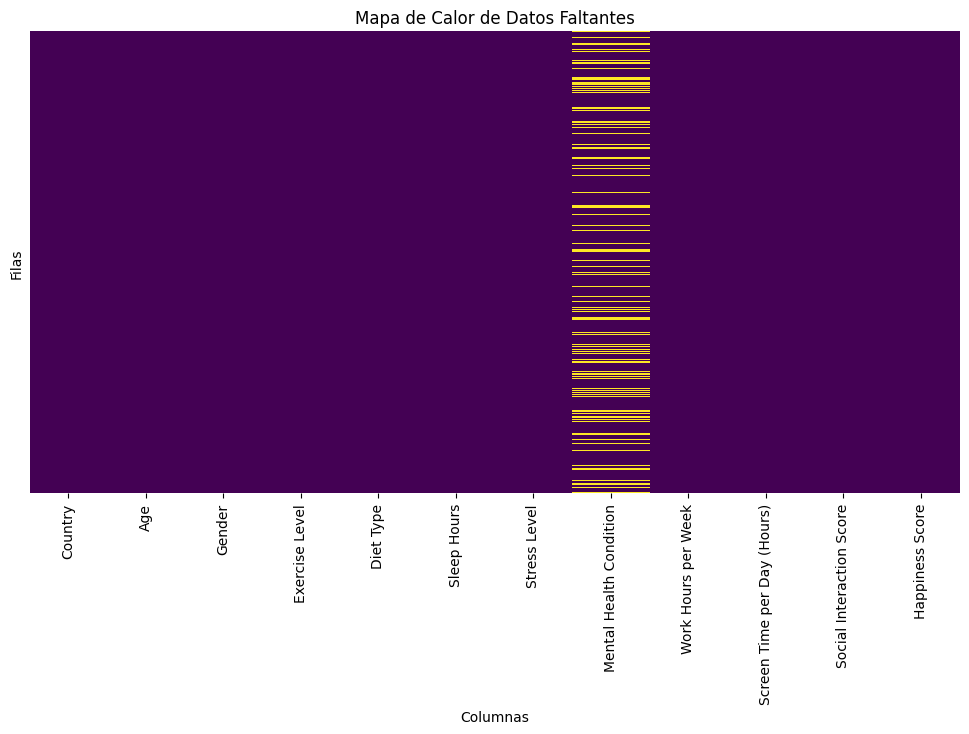

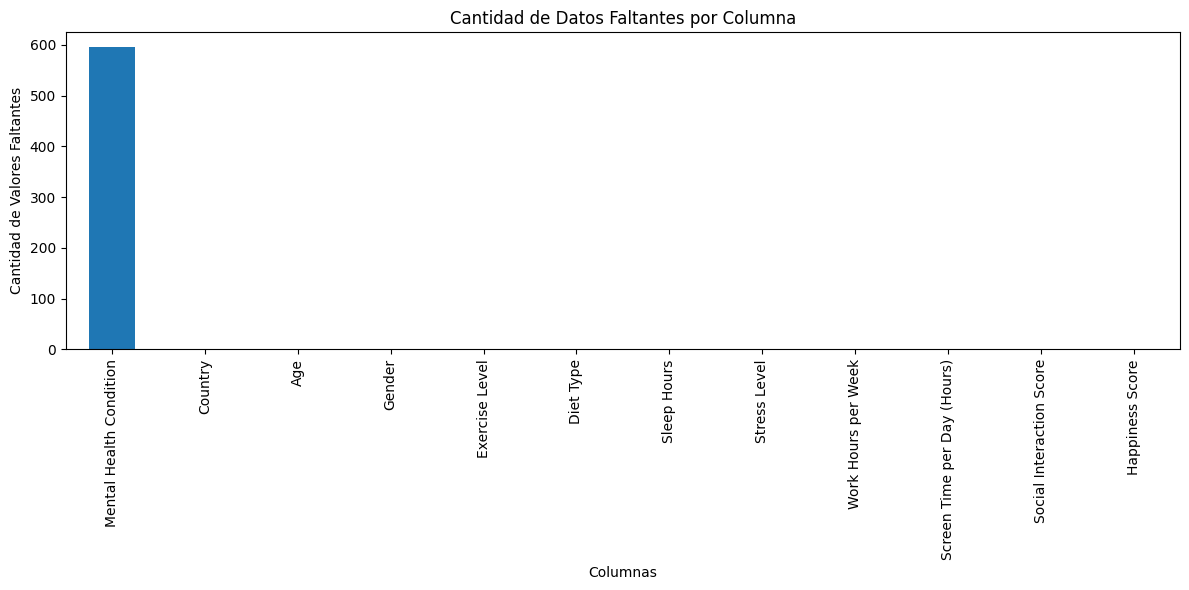

In [40]:
# Visualización de datos faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Calor de Datos Faltantes')
plt.xlabel('Columnas')
plt.ylabel('Filas')
plt.show()

# Gráfico de barras para mostrar la cantidad de datos faltantes por columna
plt.figure(figsize=(12, 6))
df.isnull().sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Cantidad de Datos Faltantes por Columna')
plt.xlabel('Columnas')
plt.ylabel('Cantidad de Valores Faltantes')
plt.tight_layout()
plt.show()
